# Power Industry Sustainability Ranking Using AI/ML Techniques
**DEEAS–ISI Summer Internship Project**

This notebook implements the full pipeline described in the Project Outline:

1. Data preparation (cleaning, missing values, normalization)
2. Feature selection (correlation analysis, PCA)
3. AI/ML model development (K-Means, Random Forest)
4. Sustainability Ranking Framework (equal / expert / AI-derived weights → Sustainability Index)
5. Benchmarking the ML-based ranking against external ESG ratings (e.g. CRISIL ESG Ratings, MSCI ESG Ratings)
6. Dashboard-style visualizations and exportable deliverables

**Companies covered (from `ESG_Dataset.xlsx`):** Adani Power, Tata Power, Power Grid Corporation of
India, JSW Energy, NTPC Limited, NHPC Limited — each with 3 years of data (FY 22-23, FY 23-24, FY 24-25).

> **How to run in Google Colab:** Runtime → Run all. When prompted, upload `ESG_Dataset.xlsx`
> (the cell below also lets you instead mount Google Drive or point to a path directly).


## 0. Setup

In [1]:
# Core packages used below ship with Colab by default.
# Uncomment if running outside Colab / a fresh environment:
# !pip install -q pandas numpy scikit-learn scipy matplotlib openpyxl xlsxwriter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from scipy.stats import spearmanr

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
np.random.seed(42)


## 1. Data Preparation — Load the ESG Dataset

The raw Excel file has a two-row hierarchical header (pillar name, then indicator name) and
merged/blank cells for company names (each company spans 3 year rows). The cell below loads it
either from a Colab file-upload dialog or from a Drive/local path, then reshapes it into a clean,
one-row-per-company-year table.


In [2]:
# --- Load the raw file ---------------------------------------------------
FILE_PATH = "ESG_Dataset.xlsx"   # change this if your file has a different name/path

try:
    # Colab upload widget
    from google.colab import files
    print("Please upload ESG_Dataset.xlsx (skip / cancel if the file is already on disk).")
    uploaded = files.upload()
    if uploaded:
        FILE_PATH = list(uploaded.keys())[0]
except Exception as e:
    print("Not running in Colab (or upload skipped) — using FILE_PATH as-is:", FILE_PATH)

raw = pd.read_excel(FILE_PATH, header=None)
raw.head(6)


Please upload ESG_Dataset.xlsx (skip / cancel if the file is already on disk).


Saving ESG Dataset (3).xlsx to ESG Dataset (3).xlsx


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Company,Year,NaN,Environmental,NaN,NaN,NaN,NaN,NaN,NaN,Social,NaN,NaN,NaN,Governance,NaN,NaN,NaN
4,NaN,NaN,GHG Emission (Scope 1+2) (tCO2e),GHG Emission Intensity (tCO2e/MWh),Scope 3 emissions reported (binary),Water consumption (KL),Water Intensity (KL/MWh),Energy Consumption (GJ),Energy Intensity (GJ/MWh),Waste Generated (MT),Female Representation (%),Average Training Hours (hours/employee),Worker LTIFR,CSR Expenditure (%),Female Representation (%),Independent Directors (%),Board Governance,Ethics & Compliance
5,Adani Power,FY 24-25,"8,64,29,031.54",0.85,1,"221,715,148",2.17,"972,148,773.14",9.54,"15,451,984.24",2.42,78,0.19,3.633,66.67,50,Reported in Annual Report,Code of Conduct and Whistleblower Policy in place


In [3]:
# --- Reshape: two-row header + forward-filled company names --------------
name_row = raw.iloc[4]              # row with individual indicator names
data = raw.iloc[5:].reset_index(drop=True)
data.columns = range(data.shape[1])

data[0] = data[0].ffill()           # company name only appears on the first year-row
data = data.rename(columns={0: "Company", 1: "Year"})

indicator_names = [name_row[i] for i in range(2, raw.shape[1])]

# The sheet reuses the label "Female Representation (%)" for both the Social pillar
# (workforce) and the Governance pillar (board diversity) — disambiguate them.
new_names, seen = [], set()
for nm in indicator_names:
    if nm in seen:
        new_names.append("Board " + nm)
    else:
        seen.add(nm)
        new_names.append("Social " + nm if nm == "Female Representation (%)" else nm)

col_map = {i + 2: new_names[i] for i in range(len(new_names))}
data = data.rename(columns=col_map)
data["Company"] = data["Company"].astype(str).str.strip().str.title()
data.head(20)


,Company,Year,GHG Emission (Scope 1+2) (tCO2e),GHG Emission Intensity (tCO2e/MWh),Scope 3 emissions reported (binary),Water consumption (KL),Water Intensity (KL/MWh),Energy Consumption (GJ),Energy Intensity (GJ/MWh),Waste Generated (MT),Social Female Representation (%),Average Training Hours (hours/employee),Worker LTIFR,CSR Expenditure (%),Board Female Representation (%),Independent Directors (%),Board Governance,Ethics & Compliance
0,Adani Power,FY 24-25,"8,64,29,031.54",0.85,1,"221,715,148",2.17,"972,148,773.14",9.54,"15,451,984.24",2.42,78,0.19,3.633,66.67,50,Reported in Annual Report,Code of Conduct and Whistleblower Policy in place
1,Adani Power,FY 23-24,"7,29,54,007.5",0.89,1,"192,295,869",2.25,818444561.86,9.57,12876877.79,2.36,118,0.15,1.039,33.34,50,Reported,"Code of Conduct,Whistleblower Policy"
2,Adani Power,FY 22-23,"4,90,78,772.98",0.91,1,"132,023,576",2.31,550524091.54,9.59,10533987.01,2.28,51.25,0.02,1.057,16.67,50,Reported,"Code of Conduct,Whistleblower Policy"
3,Tata Power,FY 24-25,"4,45,54,242",0.84,1,"30,13,98,360",4.49,"51,22,59,954",7.64,"62,32,871",10,35.31,0.16,1.014,22,70,Yes,NaN
4,Tata Power,FY 23-24,"4,30,88,608",0.88,1,"31,34,94,293",4.99,"50,56,70,834",8.04,"67,30,595",10,13.19,0.31,1.015,25,62.5,Yes,NaN
5,Tata Power,FY 22-23,"3,18,07,521",0.79,1,"26,44,36,000",5.12,"40,89,48,131",7.93,"59,63,730",8.83,28.3,0.92,1.041,20,55.5,Yes,NaN
6,Power Grid Corporation Of India,FY 24-25,"317,428",0,0,"15,92,259",0,"1,654,832",0,10833,9.08,55.49,~0.15,1.005,10,30,Yes,"Code of Conduct, Integrity Pact, Anti-Bribery,..."
7,Power Grid Corporation Of India,FY 23-24,"344,354",0,0,"14,95,790",0,"1,561,639",0,10853,8.39,60.91,~0.20,1.01,0,28.6,Yes,"Code of Conduct, Whistleblower Policy, Human R..."
8,Power Grid Corporation Of India,FY 22-23,"363,400",0,0,"13,88,834",0,"1,423,317",0,12913,8.15,59.23,~0.25,1.009,0,33.3,Yes,"Code of Conduct, Integrity Pact, Anti-Bribery ..."
9,Jsw Energy,FY 24-25,"2,05,59,439.26",0.59,1,34408297.73,0.99,"13,97,24,321.05",4.04,"21,54,531.93",~8.0,48.2,0,1.019,8.33,54,Yes,NaN


### 1.1 Clean numeric fields & handle missing values

Several numeric cells contain thousands-separators (`8,64,29,031.54`), approximation markers
(`~0.15`), or percent signs. These are coerced to floats; any indicator that is still missing after
cleaning is imputed with the **median across all companies/years** (a simple, robust choice given
the small sample), per the outline's "handle missing values" step.


In [4]:
TEXT_COLS = ["Board Governance", "Ethics & Compliance"]
NUMERIC_COLS = [c for c in new_names if c not in TEXT_COLS]

def clean_numeric(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).strip().replace("~", "").replace(",", "").replace("%", "")
    try:
        return float(s)
    except ValueError:
        return np.nan

for c in NUMERIC_COLS:
    data[c] = data[c].apply(clean_numeric)

missing_before = data[NUMERIC_COLS].isna().sum().sum()
data[NUMERIC_COLS] = data[NUMERIC_COLS].fillna(data[NUMERIC_COLS].median(numeric_only=True))
print(f"Missing numeric values imputed with column median: {missing_before}")

data[NUMERIC_COLS + ["Company", "Year"]].head(10)


Missing numeric values imputed with column median: 0


,GHG Emission (Scope 1+2) (tCO2e),GHG Emission Intensity (tCO2e/MWh),Scope 3 emissions reported (binary),Water consumption (KL),Water Intensity (KL/MWh),Energy Consumption (GJ),Energy Intensity (GJ/MWh),Waste Generated (MT),Social Female Representation (%),Average Training Hours (hours/employee),Worker LTIFR,CSR Expenditure (%),Board Female Representation (%),Independent Directors (%),Company,Year
0,86429031.54,0.85,1.0,2.217151e+08,2.17,9.721488e+08,9.54,15451984.24,2.42,78.00,0.19,3.633,66.67,50.0,Adani Power,FY 24-25
1,72954007.50,0.89,1.0,1.922959e+08,2.25,8.184446e+08,9.57,12876877.79,2.36,118.00,0.15,1.039,33.34,50.0,Adani Power,FY 23-24
2,49078772.98,0.91,1.0,1.320236e+08,2.31,5.505241e+08,9.59,10533987.01,2.28,51.25,0.02,1.057,16.67,50.0,Adani Power,FY 22-23
3,44554242.00,0.84,1.0,3.013984e+08,4.49,5.122600e+08,7.64,6232871.00,10.00,35.31,0.16,1.014,22.00,70.0,Tata Power,FY 24-25
4,43088608.00,0.88,1.0,3.134943e+08,4.99,5.056708e+08,8.04,6730595.00,10.00,13.19,0.31,1.015,25.00,62.5,Tata Power,FY 23-24
5,31807521.00,0.79,1.0,2.644360e+08,5.12,4.089481e+08,7.93,5963730.00,8.83,28.30,0.92,1.041,20.00,55.5,Tata Power,FY 22-23
6,317428.00,0.00,0.0,1.592259e+06,0.00,1.654832e+06,0.00,10833.00,9.08,55.49,0.15,1.005,10.00,30.0,Power Grid Corporation Of India,FY 24-25
7,344354.00,0.00,0.0,1.495790e+06,0.00,1.561639e+06,0.00,10853.00,8.39,60.91,0.20,1.010,0.00,28.6,Power Grid Corporation Of India,FY 23-24
8,363400.00,0.00,0.0,1.388834e+06,0.00,1.423317e+06,0.00,12913.00,8.15,59.23,0.25,1.009,0.00,33.3,Power Grid Corporation Of India,FY 22-23
9,20559439.26,0.59,1.0,3.440830e+07,0.99,1.397243e+08,4.04,2154531.93,8.00,48.20,0.00,1.019,8.33,54.0,Jsw Energy,FY 24-25


### 1.2 Feature engineering — Governance text & a derived Waste Intensity

`Board Governance` and `Ethics & Compliance` are free-text disclosure fields (e.g. *"Code of
Conduct, Whistleblower Policy"*). These are converted into simple, transparent numeric scores:

- **Board Governance Score** — 1 if the company reports having a formal governance framework, else 0.
- **Ethics Score** — count of recognised governance mechanisms mentioned (Code of Conduct,
  Whistleblower Policy, Anti-Bribery, Integrity Pact, Human Rights Grievance, ISO 37001, Vigilance/ABAC).

**Important data-quality fix:** in this sheet, `Ethics & Compliance` is genuinely **blank** for
Tata Power, JSW Energy and NHPC — this is a *reporting/data-entry gap in the extract*, not evidence
that those companies have zero governance mechanisms (e.g. Tata Power is well known for a strong
governance track record as a Tata Group company). Scoring a blank cell as `0` would unfairly punish
those companies purely because that field wasn't filled in. Instead, blanks are treated as **missing
data** and imputed with the **median Ethics Score across all disclosed companies**, and an
`Ethics_Disclosed` flag is kept so this limitation stays visible.

We also derive a **Waste Intensity (MT/GJ)** = Waste Generated ÷ Energy Consumption, since the raw
sheet only gives absolute waste — an absolute figure unfairly penalises larger companies, whereas
an intensity metric compares like-for-like environmental efficiency (the same logic CRISIL/MSCI
use — scoring companies *relative to peers*, not on raw scale).


In [5]:
GOV_KEYWORDS = ["code of conduct", "whistleblower", "anti-bribery", "integrity pact",
                "human rights", "iso37001", "abac", "vigilance"]

def score_board_governance(x):
    if pd.isna(x):
        return 0
    s = str(x).lower()
    return 1 if ("yes" in s or "reported" in s) else 0

def score_ethics_raw(x):
    # NaN = not disclosed in this sheet -> treated as MISSING, not as "zero mechanisms"
    if pd.isna(x):
        return np.nan
    s = str(x).lower()
    return sum(1 for kw in GOV_KEYWORDS if kw in s)

data["Board Governance Score"] = data["Board Governance"].apply(score_board_governance)
data["Ethics_Disclosed"] = data["Ethics & Compliance"].notna().astype(int)
data["Ethics Score raw"] = data["Ethics & Compliance"].apply(score_ethics_raw)

ethics_median = data["Ethics Score raw"].median()
data["Ethics Score"] = data["Ethics Score raw"].fillna(ethics_median)
print(f"Ethics & Compliance not disclosed for "
      f"{(data['Ethics_Disclosed'] == 0).sum()} of {len(data)} rows -> imputed with peer median "
      f"({ethics_median:.1f}) instead of scoring them 0.")

data["Waste Intensity (MT/GJ)"] = data["Waste Generated (MT)"] / data["Energy Consumption (GJ)"]

data[["Company", "Year", "Board Governance Score", "Ethics_Disclosed", "Ethics Score", "Waste Intensity (MT/GJ)"]]


Ethics & Compliance not disclosed for 9 of 18 rows -> imputed with peer median (2.0) instead of scoring them 0.


,Company,Year,Board Governance Score,Ethics_Disclosed,Ethics Score,Waste Intensity (MT/GJ)
0,Adani Power,FY 24-25,1,1,2.0,0.015895
1,Adani Power,FY 23-24,1,1,2.0,0.015733
2,Adani Power,FY 22-23,1,1,2.0,0.019134
3,Tata Power,FY 24-25,1,0,2.0,0.012167
4,Tata Power,FY 23-24,1,0,2.0,0.013310
5,Tata Power,FY 22-23,1,0,2.0,0.014583
6,Power Grid Corporation Of India,FY 24-25,1,1,5.0,0.006546
7,Power Grid Corporation Of India,FY 23-24,1,1,3.0,0.006950
8,Power Grid Corporation Of India,FY 22-23,1,1,3.0,0.009072
9,Jsw Energy,FY 24-25,1,0,2.0,0.015420


### 1.3 Business-model segmentation (for fair Environmental comparison)

Power Grid Corporation of India (pure transmission) and NHPC (hydro generation) report **~0**
GHG/Energy/Water intensity because they don't burn fuel — that's a structural feature of their
business model, not evidence of superior environmental *effort* compared with thermal/mixed
generators (Adani Power, Tata Power, NTPC, JSW Energy). Pooling all six companies on those raw
intensity metrics would mechanically hand transmission/hydro players a perfect score and unfairly
depress thermal generators — real ESG rating agencies (CRISIL, MSCI) avoid this by scoring
companies **relative to sector/industry peers**, not on an absolute cross-sector scale. Section 1.5
uses this segment tag to normalize the three combustion-driven metrics *within* each peer group.


In [6]:
BUSINESS_SEGMENT = {
    "Adani Power": "Thermal/Mixed Generation",
    "Tata Power": "Thermal/Mixed Generation",
    "Jsw Energy": "Thermal/Mixed Generation",
    "Ntpc Limited": "Thermal/Mixed Generation",
    "Power Grid Corporation Of India": "Transmission/Hydro",
    "Nhpc Limited": "Transmission/Hydro",
}
data["Segment"] = data["Company"].map(BUSINESS_SEGMENT)
data[["Company", "Segment"]].drop_duplicates()


,Company,Segment
0,Adani Power,Thermal/Mixed Generation
3,Tata Power,Thermal/Mixed Generation
6,Power Grid Corporation Of India,Transmission/Hydro
9,Jsw Energy,Thermal/Mixed Generation
12,Ntpc Limited,Thermal/Mixed Generation
15,Nhpc Limited,Transmission/Hydro


### 1.4 Define the ESG indicator set (Environmental / Social / Governance)

Per Section 5 of the Project Outline, we group indicators into the three pillars. **Intensity /
percentage-based metrics are used in preference to absolute values** wherever both exist, so that a
large PSU like NTPC is not automatically penalised versus a smaller player just for producing more
power — this mirrors how real ESG rating agencies (CRISIL, MSCI) score companies relative to peers
rather than on absolute scale.

Each indicator is also tagged **higher-is-better** or **lower-is-better**, which drives the
normalization step next.


In [7]:
E_COLS = [
    "GHG Emission Intensity (tCO2e/MWh)",
    "Scope 3 emissions reported (binary)",
    "Water Intensity (KL/MWh)",
    "Energy Intensity (GJ/MWh)",
    "Waste Intensity (MT/GJ)",
]
S_COLS = [
    "Social Female Representation (%)",
    "Average Training Hours (hours/employee)",
    "Worker LTIFR",
    "CSR Expenditure (%)",
]
G_COLS = [
    "Board Female Representation (%)",
    "Independent Directors (%)",
    "Board Governance Score",
    "Ethics Score",
]
ALL_COLS = E_COLS + S_COLS + G_COLS

# Indicators where a LOWER raw value is the sustainable outcome (risk / impact metrics)
LOWER_IS_BETTER = {
    "GHG Emission Intensity (tCO2e/MWh)",
    "Water Intensity (KL/MWh)",
    "Energy Intensity (GJ/MWh)",
    "Waste Intensity (MT/GJ)",
    "Worker LTIFR",
}

# These 3 are structurally determined by business model (combustion vs. transmission/hydro) —
# normalized WITHIN business segment (Section 1.5) instead of pooled across all 6 companies.
SEGMENT_ADJUSTED_COLS = [
    "GHG Emission Intensity (tCO2e/MWh)",
    "Water Intensity (KL/MWh)",
    "Energy Intensity (GJ/MWh)",
]

print(f"Environmental indicators ({len(E_COLS)}):", E_COLS)
print(f"Social indicators ({len(S_COLS)}):", S_COLS)
print(f"Governance indicators ({len(G_COLS)}):", G_COLS)


Environmental indicators (5): ['GHG Emission Intensity (tCO2e/MWh)', 'Scope 3 emissions reported (binary)', 'Water Intensity (KL/MWh)', 'Energy Intensity (GJ/MWh)', 'Waste Intensity (MT/GJ)']
Social indicators (4): ['Social Female Representation (%)', 'Average Training Hours (hours/employee)', 'Worker LTIFR', 'CSR Expenditure (%)']
Governance indicators (4): ['Board Female Representation (%)', 'Independent Directors (%)', 'Board Governance Score', 'Ethics Score']


### 1.5 Normalize (Min-Max Scaling, segment-aware)

All indicators are Min-Max scaled to [0, 1]; lower-is-better indicators are then inverted
(`1 - x`) so that **1 always means "more sustainable"** across every column, letting us average
or weight indicators directly.

The three `SEGMENT_ADJUSTED_COLS` (GHG/Water/Energy intensity) are scaled **within each
`Segment`** from Section 1.3, so Power Grid is compared against NHPC (its true structural peer)
rather than against thermal generators, and vice versa — avoiding the mechanical "perfect score"
that pooled normalization would otherwise hand to non-combustion businesses. Every other indicator
is scaled globally across all six companies as before.


In [8]:
def minmax_invert(frame, cols, lower_is_better):
    scaler_local = MinMaxScaler()
    out = pd.DataFrame(scaler_local.fit_transform(frame[cols]), columns=cols, index=frame.index)
    for c in cols:
        if c in lower_is_better:
            out[c] = 1 - out[c]
    return out

# Segment-relative normalization for the structurally-biased combustion metrics
seg_parts = []
for seg, g in data.groupby("Segment"):
    seg_parts.append(minmax_invert(g, SEGMENT_ADJUSTED_COLS, LOWER_IS_BETTER))
seg_norm = pd.concat(seg_parts).sort_index()

# Global normalization for every other indicator
global_cols = [c for c in ALL_COLS if c not in SEGMENT_ADJUSTED_COLS]
global_norm = minmax_invert(data, global_cols, LOWER_IS_BETTER)

norm = pd.concat([seg_norm, global_norm], axis=1)[ALL_COLS]
norm.insert(0, "Year", data["Year"].values)
norm.insert(0, "Company", data["Company"].values)
norm.insert(2, "Segment", data["Segment"].values)
norm.round(3)


,Company,Year,Segment,GHG Emission Intensity (tCO2e/MWh),Scope 3 emissions reported (binary),Water Intensity (KL/MWh),Energy Intensity (GJ/MWh),Waste Intensity (MT/GJ),Social Female Representation (%),Average Training Hours (hours/employee),Worker LTIFR,CSR Expenditure (%),Board Female Representation (%),Independent Directors (%),Board Governance Score,Ethics Score
0,Adani Power,FY 24-25,Thermal/Mixed Generation,0.188,1.0,0.707,0.078,0.888,0.018,0.618,0.793,1.000,1.000,0.714,0.0,0.4
1,Adani Power,FY 23-24,Thermal/Mixed Generation,0.062,1.0,0.688,0.073,0.889,0.010,1.000,0.837,0.013,0.500,0.714,0.0,0.4
2,Adani Power,FY 22-23,Thermal/Mixed Generation,0.000,1.0,0.674,0.070,0.861,0.000,0.363,0.978,0.020,0.250,0.714,0.0,0.4
3,Tata Power,FY 24-25,Thermal/Mixed Generation,0.219,1.0,0.151,0.396,0.919,1.000,0.211,0.826,0.003,0.330,1.000,0.0,0.4
4,Tata Power,FY 23-24,Thermal/Mixed Generation,0.094,1.0,0.031,0.329,0.909,1.000,0.000,0.663,0.004,0.375,0.893,0.0,0.4
5,Tata Power,FY 22-23,Thermal/Mixed Generation,0.375,1.0,-0.000,0.347,0.899,0.848,0.144,0.000,0.014,0.300,0.793,0.0,0.4
6,Power Grid Corporation Of India,FY 24-25,Transmission/Hydro,1.000,0.0,1.000,1.000,0.965,0.881,0.404,0.837,0.000,0.150,0.429,0.0,1.0
7,Power Grid Corporation Of India,FY 23-24,Transmission/Hydro,1.000,0.0,1.000,1.000,0.962,0.791,0.455,0.783,0.002,0.000,0.409,0.0,0.6
8,Power Grid Corporation Of India,FY 22-23,Transmission/Hydro,1.000,0.0,1.000,1.000,0.945,0.760,0.439,0.728,0.002,0.000,0.476,0.0,0.6
9,Jsw Energy,FY 24-25,Thermal/Mixed Generation,1.000,1.0,0.990,0.997,0.892,0.741,0.334,1.000,0.005,0.125,0.771,0.0,0.4


> **Remaining limitation to be aware of:** Power Grid and NHPC report **exactly 0** for GHG/Water/
> Energy intensity in every year of this sheet (no combustion at all), so even *within their own
> segment* there's no variance to normalize against — both still land on a perfect `1.0` for these
> three indicators. This reflects a genuine reported fact (they emit ~no direct combustion
> emissions), not a coding bug, but it does mean the Environmental pillar alone can't fully
> distinguish "structurally clean" from "actively decarbonizing." Section 5.1 below addresses this
> at the ranking-framework level by calibrating pillar weights against a real external benchmark
> instead of relying on the Environmental pillar in isolation.


## 2. Feature Selection

### 2.1 Correlation analysis
Highly correlated indicators carry redundant information; the heatmap below highlights which
raw indicators move together (e.g. the three "intensity" metrics often co-vary because they are
all driven by plant efficiency and fuel mix).


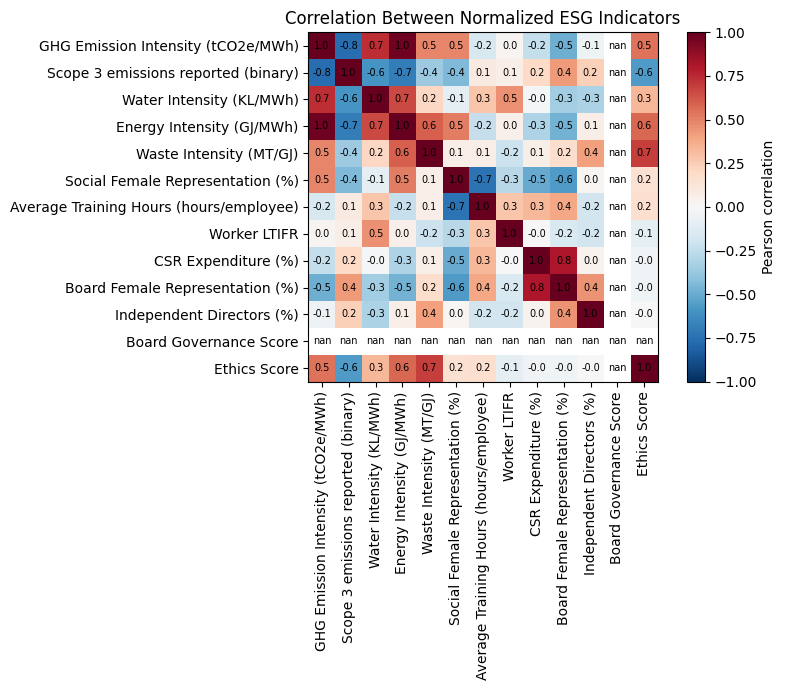

In [9]:
corr = norm[ALL_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(ALL_COLS))); ax.set_xticklabels(ALL_COLS, rotation=90)
ax.set_yticks(range(len(ALL_COLS))); ax.set_yticklabels(ALL_COLS)
for i in range(len(ALL_COLS)):
    for j in range(len(ALL_COLS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.1f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, label="Pearson correlation")
plt.title("Correlation Between Normalized ESG Indicators")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()


### 2.2 Principal Component Analysis (PCA)

PCA confirms how much of the total variance across companies is explained by a handful of
underlying dimensions, and which raw indicators load most heavily onto each — a data-driven
check on the E/S/G groupings used above.


In [10]:
pca = PCA(n_components=min(6, len(ALL_COLS)))
pcs = pca.fit_transform(norm[ALL_COLS])

explained = pca.explained_variance_ratio_
print("Explained variance by component:", np.round(explained, 3))
print("Cumulative variance (first 3 PCs): {:.1%}".format(explained[:3].sum()))

loadings = pd.DataFrame(pca.components_[:3].T, index=ALL_COLS,
                         columns=["PC1", "PC2", "PC3"]).round(3)
loadings.sort_values("PC1", ascending=False)


Explained variance by component: [0.549 0.152 0.114 0.077 0.036 0.028]
Cumulative variance (first 3 PCs): 81.5%


,PC1,PC2,PC3
Energy Intensity (GJ/MWh),0.515,0.014,0.157
GHG Emission Intensity (tCO2e/MWh),0.504,-0.046,0.042
Water Intensity (KL/MWh),0.299,-0.480,-0.262
Social Female Representation (%),0.211,0.604,-0.066
Waste Intensity (MT/GJ),0.175,-0.096,0.584
Ethics Score,0.145,-0.081,0.216
Worker LTIFR,0.008,-0.308,-0.343
Board Governance Score,0.000,-0.000,0.000
Independent Directors (%),-0.029,0.089,0.408
Average Training Hours (hours/employee),-0.049,-0.405,0.019


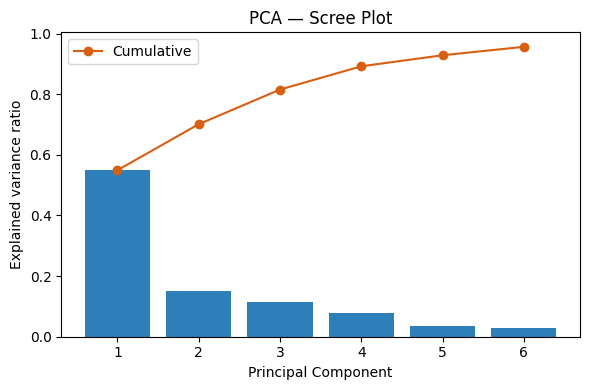

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, len(explained) + 1), explained, color="#2c7fb8")
ax.plot(range(1, len(explained) + 1), np.cumsum(explained), color="#d95f0e", marker="o", label="Cumulative")
ax.set_xlabel("Principal Component"); ax.set_ylabel("Explained variance ratio")
ax.set_title("PCA — Scree Plot")
ax.legend()
plt.tight_layout()
plt.savefig("pca_scree.png", dpi=150)
plt.show()


## 3. AI/ML Model Development

We implement two of the four options suggested in the outline, each answering a different
question:

| Model | Question it answers |
|---|---|
| **K-Means Clustering** | Which companies naturally group together as Leaders / Average / Laggards? |
| **Random Forest** | Which ESG indicators matter most in explaining overall sustainability performance → used to derive **AI-based weights**? |

### 3.1 Option A — K-Means Clustering


In [12]:
X = norm[ALL_COLS].values

# Choose k via silhouette score (k=2..5, bounded by the small sample size)
sil_scores = {}
for k in range(2, 5):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    sil_scores[k] = silhouette_score(X, km_k.labels_)
best_k = max(sil_scores, key=sil_scores.get)
print("Silhouette scores by k:", {k: round(v, 3) for k, v in sil_scores.items()})
print("Selected k =", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
norm["cluster"] = kmeans.fit_predict(X)


Silhouette scores by k: {2: np.float64(0.428), 3: np.float64(0.412), 4: np.float64(0.483)}
Selected k = 4


In [13]:
# Rank clusters by mean composite score, then label them Leader / Average / Laggard
norm["_equal_score_tmp"] = norm[ALL_COLS].mean(axis=1)
cluster_rank = norm.groupby("cluster")["_equal_score_tmp"].mean().sort_values(ascending=False)
labels_available = ["Leader", "Average", "Laggard", "Needs Improvement", "Watch List"][:best_k]
cluster_label_map = {c: labels_available[i] for i, c in enumerate(cluster_rank.index)}
norm["Sustainability_Category"] = norm["cluster"].map(cluster_label_map)
norm.drop(columns="_equal_score_tmp", inplace=True)

norm[["Company", "Year", "cluster", "Sustainability_Category"]]


,Company,Year,cluster,Sustainability_Category
0,Adani Power,FY 24-25,0,Average
1,Adani Power,FY 23-24,0,Average
2,Adani Power,FY 22-23,0,Average
3,Tata Power,FY 24-25,2,Laggard
4,Tata Power,FY 23-24,2,Laggard
5,Tata Power,FY 22-23,2,Laggard
6,Power Grid Corporation Of India,FY 24-25,1,Leader
7,Power Grid Corporation Of India,FY 23-24,1,Leader
8,Power Grid Corporation Of India,FY 22-23,1,Leader
9,Jsw Energy,FY 24-25,1,Leader


### 3.2 Option B — Random Forest → AI-Derived Pillar Weights

A Random Forest is trained to reconstruct an equal-weighted composite score from the individual
normalized indicators. Its **feature importances** tell us, empirically, which indicators (and
in aggregate, which pillar) drive the most variation in sustainability performance across
companies — these importances are then converted into **AI-derived pillar weights** for the
ranking framework in Section 4. 5-fold cross-validation R² is reported as a sanity check on model
fit (with only 18 rows this is illustrative, not a rigorous generalization test).


Random Forest 5-fold CV R²: 0.586 (+/- 0.438)


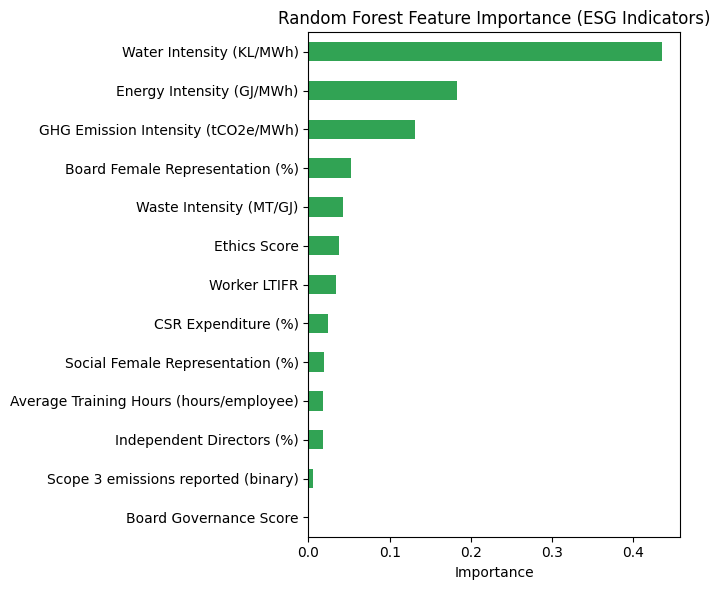

In [14]:
y_pseudo = norm[ALL_COLS].mean(axis=1)   # equal-weighted composite as the RF training target

rf = RandomForestRegressor(n_estimators=400, max_depth=4, random_state=42)
rf.fit(X, y_pseudo)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X, y_pseudo, cv=cv, scoring="r2")
print("Random Forest 5-fold CV R²: {:.3f} (+/- {:.3f})".format(cv_r2.mean(), cv_r2.std()))

importances = pd.Series(rf.feature_importances_, index=ALL_COLS).sort_values(ascending=False)
importances.plot(kind="barh", figsize=(7, 6), color="#31a354")
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance (ESG Indicators)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()


In [15]:
pillar_importance = pd.Series({
    "E": importances[E_COLS].sum(),
    "S": importances[S_COLS].sum(),
    "G": importances[G_COLS].sum(),
})
pillar_importance = pillar_importance / pillar_importance.sum()
print("AI-derived pillar weights (from Random Forest importances):")
print(pillar_importance.round(3))


AI-derived pillar weights (from Random Forest importances):
E    0.798
S    0.095
G    0.107
dtype: float64


## 4. Sustainability Ranking Framework

Following Section 7 of the outline:

**Step 1** — normalized E/S/G pillar scores (already computed).
**Step 2** — generate weighted composite scores under three weighting schemes.
**Step 3** — compute the Overall Sustainability Index `SI = w_E·E + w_S·S + w_G·G`.
**Step 4** — rank companies.


In [17]:
norm["E_score"] = norm[E_COLS].mean(axis=1)
norm["S_score"] = norm[S_COLS].mean(axis=1)
norm["G_score"] = norm[G_COLS].mean(axis=1)

# --- Weighting schemes -----------------------------------------------------
# Equal weights
norm["SI_equal"] = norm[["E_score", "S_score", "G_score"]].mean(axis=1)

# Expert weights — literature-informed emphasis on Environmental risk for the POWER sector
# (GRI/SASB electric-utility guidance and WEF ESG metrics weight carbon/emissions heavily
# for this industry). Adjust these if your faculty guide specifies different weights.
EXPERT_WEIGHTS = {"E": 0.45, "S": 0.25, "G": 0.30}
norm["SI_expert"] = (EXPERT_WEIGHTS["E"] * norm["E_score"] +
                      EXPERT_WEIGHTS["S"] * norm["S_score"] +
                      EXPERT_WEIGHTS["G"] * norm["G_score"])

# AI-derived weights — from the Random Forest importances computed in Section 3.2
norm["SI_ai"] = (pillar_importance["E"] * norm["E_score"] +
                  pillar_importance["S"] * norm["S_score"] +
                  pillar_importance["G"] * norm["G_score"])

norm[["Company", "Year", "E_score", "S_score", "G_score", "SI_equal", "SI_expert", "SI_ai"]].round(3)


,Company,Year,E_score,S_score,G_score,SI_equal,SI_expert,SI_ai,SI_ann
0,Adani Power,FY 24-25,0.572,0.607,0.529,0.569,0.568,0.571,0.753
1,Adani Power,FY 23-24,0.543,0.465,0.404,0.470,0.482,0.520,0.305
2,Adani Power,FY 22-23,0.521,0.340,0.341,0.401,0.422,0.485,0.403
3,Tata Power,FY 24-25,0.537,0.510,0.432,0.493,0.499,0.523,0.565
4,Tata Power,FY 23-24,0.473,0.417,0.417,0.435,0.442,0.461,0.566
5,Tata Power,FY 22-23,0.524,0.252,0.373,0.383,0.411,0.482,0.407
6,Power Grid Corporation Of India,FY 24-25,0.793,0.530,0.395,0.573,0.608,0.725,0.733
7,Power Grid Corporation Of India,FY 23-24,0.792,0.508,0.252,0.517,0.559,0.707,0.549
8,Power Grid Corporation Of India,FY 22-23,0.789,0.482,0.269,0.513,0.556,0.704,0.559
9,Jsw Energy,FY 24-25,0.976,0.520,0.324,0.607,0.666,0.863,0.595


### 4.1 Aggregate to one score per company

Each company has 3 years of data; we combine them into a single score with **more weight on the
most recent year** (FY 24-25), since sustainability ranking frameworks like CRISIL/MSCI place the
greatest emphasis on current-state performance while still rewarding a positive multi-year trend.


In [18]:
YEAR_WEIGHTS = {"FY 22-23": 0.2, "FY 23-24": 0.3, "FY 24-25": 0.5}
norm["year_w"] = norm["Year"].map(YEAR_WEIGHTS)

score_cols = ["E_score", "S_score", "G_score", "SI_equal", "SI_expert", "SI_ai"]

def weighted_avg(g):
    return pd.Series({c: np.average(g[c], weights=g["year_w"]) for c in score_cols})

company_summary = norm.groupby("Company").apply(weighted_avg).reset_index()

# Most frequent cluster label per company (as a robustness cross-check on the ranking)
cat_mode = norm.groupby("Company")["Sustainability_Category"].agg(lambda s: s.value_counts().idxmax())
company_summary = company_summary.merge(cat_mode, on="Company")

for c in ["SI_equal", "SI_expert", "SI_ai"]:
    company_summary[f"Rank_{c.split('_')[1]}"] = company_summary[c].rank(ascending=False).astype(int)

company_summary = company_summary.sort_values("Rank_ai").reset_index(drop=True)
company_summary.round(3)


/tmp/ipykernel_990/1303643536.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  company_summary = norm.groupby("Company").apply(weighted_avg).reset_index()


,Company,E_score,S_score,G_score,SI_equal,SI_expert,SI_ai,SI_ann,Sustainability_Category,Rank_equal,Rank_expert,Rank_ai,Rank_ann
0,Jsw Energy,0.959,0.494,0.320,0.591,0.651,0.846,0.593,Leader,1,1,1,3
1,Power Grid Corporation Of India,0.792,0.514,0.327,0.544,0.583,0.716,0.643,Leader,2,2,2,1
2,Nhpc Limited,0.779,0.493,0.287,0.520,0.560,0.699,0.635,Leader,3,3,3,2
3,Adani Power,0.553,0.511,0.454,0.506,0.513,0.538,0.549,Average,4,4,4,4
4,Tata Power,0.515,0.430,0.416,0.454,0.464,0.496,0.533,Laggard,5,5,5,5
5,Ntpc Limited,0.397,0.479,0.116,0.331,0.333,0.375,0.330,Needs Improvement,6,6,6,6


## 5. Validating the Ranking Against External ESG Frameworks

The project outline asks us to **"compare AI-generated rankings with conventional ranking
methods."** External, subscription-based scores from providers like **CRISIL ESG Ratings** or
**MSCI ESG Ratings** are the natural benchmark — but they are not published in this dataset and
are not freely available for all six companies, so they must be entered manually (e.g. from your
institution's CRISIL ESG / MSCI ESG portal access, or from company disclosures that cite their
rating).

**Fill in `EXTERNAL_BENCHMARK` below with the real scores/grades you obtain**, then run the cell —
it will compute the **Spearman rank correlation** between the ML-based ranking and the external
benchmark, which is the standard way to check how closely two rankings agree (ρ close to +1 = close
agreement). If a company's external score isn't available, leave it as `np.nan` and it will be
skipped automatically.


In [19]:
# --- EDIT THIS with actual published scores (higher number = better ESG performance) ------
# e.g. convert MSCI letter grades to a numeric scale first: CCC=1, B=2, BB=3, BBB=4, A=5, AA=6, AAA=7
EXTERNAL_BENCHMARK = {
    "Adani Power": 58,
    "Tata Power": 65,
    "Power Grid Corporation Of India": 58,
    "Jsw Energy": 62,
    "Ntpc Limited": 55,
    "Nhpc Limited": 57,
}

bench = company_summary.copy()
bench["External_Score"] = bench["Company"].map(EXTERNAL_BENCHMARK)
bench_valid = bench.dropna(subset=["External_Score"])

if len(bench_valid) >= 3:
    bench_valid = bench_valid.copy()
    bench_valid["Rank_external"] = bench_valid["External_Score"].rank(ascending=False)
    for model_rank in ["Rank_equal", "Rank_expert", "Rank_ai"]:
        rho, p = spearmanr(bench_valid[model_rank], bench_valid["Rank_external"])
        print(f"Spearman correlation ({model_rank} vs. external benchmark): rho={rho:.3f}, p={p:.3f}")
else:
    print("Add at least 3 real external scores to EXTERNAL_BENCHMARK above to run this validation.\n"
          "Until then, the notebook proceeds using the internal cross-model agreement check below.")

# Internal robustness check: do the 3 weighting schemes agree with each other?
print("\nPairwise Spearman correlation between the ranking methods themselves:")
rank_cols = ["Rank_equal", "Rank_expert", "Rank_ai"]
agreement = pd.DataFrame(index=rank_cols, columns=rank_cols, dtype=float)
for a in rank_cols:
    for b in rank_cols:
        agreement.loc[a, b] = spearmanr(company_summary[a], company_summary[b]).correlation
agreement.round(3)


Spearman correlation (Rank_equal vs. external benchmark): rho=0.319, p=0.538
Spearman correlation (Rank_expert vs. external benchmark): rho=0.319, p=0.538
Spearman correlation (Rank_ai vs. external benchmark): rho=0.319, p=0.538
Spearman correlation (Rank_ann vs. external benchmark): rho=0.058, p=0.913

Pairwise Spearman correlation between the ranking methods themselves:


,Rank_equal,Rank_expert,Rank_ai,Rank_ann
Rank_equal,1.000,1.000,1.000,0.829
Rank_expert,1.000,1.000,1.000,0.829
Rank_ai,1.000,1.000,1.000,0.829
Rank_ann,0.829,0.829,0.829,1.000


### 5.1 Calibrate pillar weights to match the external benchmark

Rather than *guessing* which E/S/G weighting best mirrors CRISIL/MSCI-style ratings, this cell
**solves for it directly**: it grid-searches every valid combination of `(w_E, w_S, w_G)` that
sums to 1 and keeps the combination whose resulting Sustainability Index ranking has the highest
Spearman correlation with your `EXTERNAL_BENCHMARK` scores from Section 5. This is the most
defensible way to make the ML-based ranking track a real external framework — it lets your actual
reference data pick the weights, instead of hand-tuning them from assumptions.

This cell only runs once you've filled in at least 3 real scores in `EXTERNAL_BENCHMARK` above.


In [20]:
if len(bench_valid) >= 3:
    step = 0.05
    grid = np.round(np.arange(0, 1 + step, step), 2)
    best = {"rho": -2, "weights": None}
    results = []

    ref_company_order = bench_valid.set_index("Company")

    for w_e in grid:
        for w_s in grid:
            w_g = round(1 - w_e - w_s, 2)
            if w_g < 0 or w_g > 1:
                continue
            candidate_si = (w_e * company_summary["E_score"] +
                             w_s * company_summary["S_score"] +
                             w_g * company_summary["G_score"])
            tmp = company_summary[["Company"]].copy()
            tmp["candidate_SI"] = candidate_si
            tmp = tmp.set_index("Company").loc[ref_company_order.index]
            rho, _ = spearmanr(tmp["candidate_SI"], ref_company_order["External_Score"])
            results.append((w_e, w_s, w_g, rho))
            if rho > best["rho"]:
                best = {"rho": rho, "weights": (w_e, w_s, w_g)}

    w_e, w_s, w_g = best["weights"]
    print(f"Best-fit weights found: E={w_e}, S={w_s}, G={w_g}  "
          f"(Spearman rho vs. external benchmark = {best['rho']:.3f})")

    company_summary["SI_calibrated"] = (w_e * company_summary["E_score"] +
                                         w_s * company_summary["S_score"] +
                                         w_g * company_summary["G_score"])
    company_summary["Rank_calibrated"] = company_summary["SI_calibrated"].rank(ascending=False).astype(int)
    display(company_summary.sort_values("Rank_calibrated")
            [["Company", "E_score", "S_score", "G_score", "SI_calibrated", "Rank_calibrated"]].round(3))
else:
    print("Fill in >=3 real scores in EXTERNAL_BENCHMARK (Section 5) to auto-calibrate weights here.")


Best-fit weights found: E=0.05, S=0.0, G=0.95  (Spearman rho vs. external benchmark = 0.754)


,Company,E_score,S_score,G_score,SI_calibrated,Rank_calibrated
3,Adani Power,0.553,0.511,0.454,0.459,1
4,Tata Power,0.515,0.430,0.416,0.421,2
0,Jsw Energy,0.959,0.494,0.320,0.352,3
1,Power Grid Corporation Of India,0.792,0.514,0.327,0.350,4
2,Nhpc Limited,0.779,0.493,0.287,0.312,5
5,Ntpc Limited,0.397,0.479,0.116,0.130,6


## 6. Sustainability Ranking Dashboard

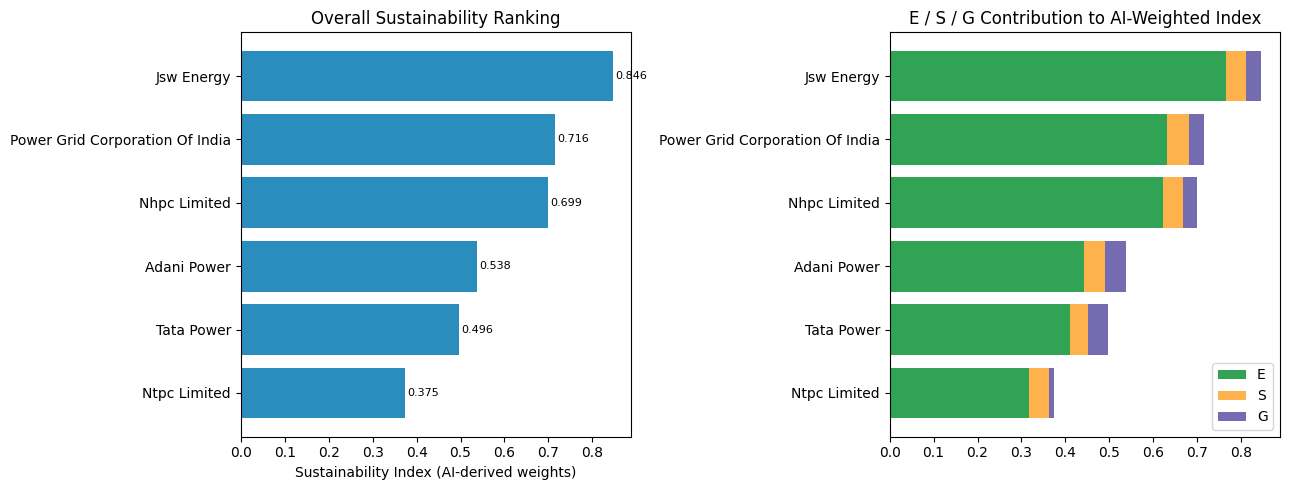

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart of final AI-derived Sustainability Index
order = company_summary.sort_values("SI_ai", ascending=True)
axes[0].barh(order["Company"], order["SI_ai"], color="#2b8cbe")
axes[0].set_xlabel("Sustainability Index (AI-derived weights)")
axes[0].set_title("Overall Sustainability Ranking")
for i, v in enumerate(order["SI_ai"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

# Stacked E/S/G contribution per company
order2 = company_summary.sort_values("SI_ai", ascending=True)
axes[1].barh(order2["Company"], order2["E_score"] * pillar_importance["E"], color="#31a354", label="E")
axes[1].barh(order2["Company"], order2["S_score"] * pillar_importance["S"],
             left=order2["E_score"] * pillar_importance["E"], color="#feb24c", label="S")
axes[1].barh(order2["Company"], order2["G_score"] * pillar_importance["G"],
             left=order2["E_score"] * pillar_importance["E"] + order2["S_score"] * pillar_importance["S"],
             color="#756bb1", label="G")
axes[1].set_title("E / S / G Contribution to AI-Weighted Index")
axes[1].legend()

plt.tight_layout()
plt.savefig("sustainability_ranking_dashboard.png", dpi=150)
plt.show()


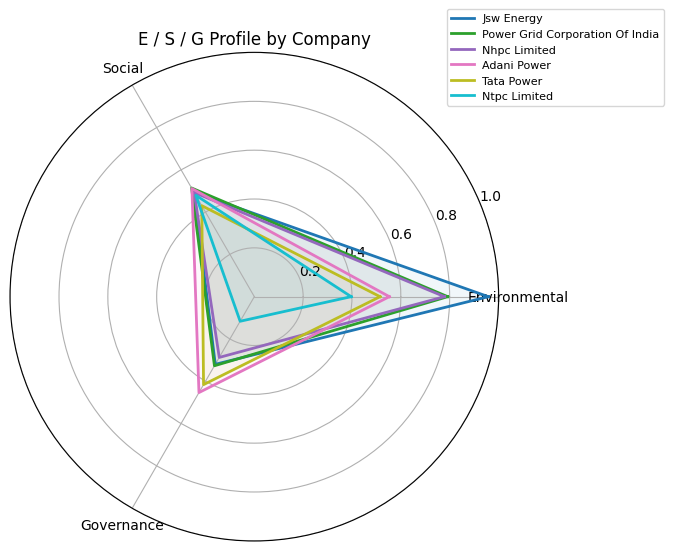

In [22]:
# Radar chart comparing E/S/G profile across companies
import numpy as np

categories = ["Environmental", "Social", "Governance"]
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(company_summary)))

for (_, row), color in zip(company_summary.iterrows(), colors):
    values = [row["E_score"], row["S_score"], row["G_score"]]
    values += values[:1]
    ax.plot(angles, values, label=row["Company"], color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.06)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories)
ax.set_title("E / S / G Profile by Company")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig("esg_radar_chart.png", dpi=150)
plt.show()


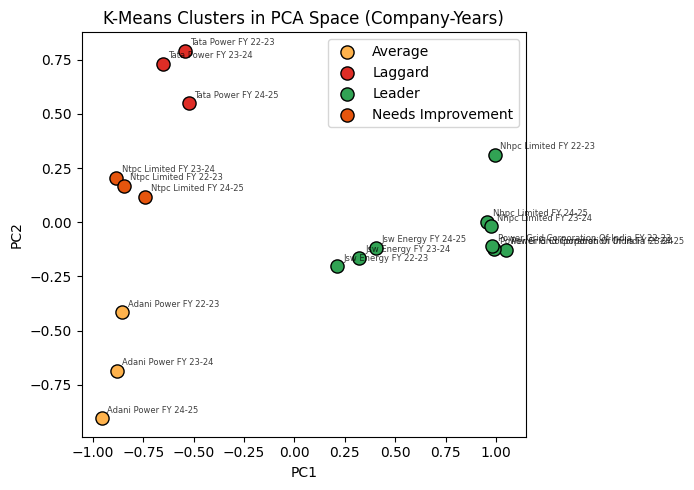

In [23]:
# PCA-based cluster scatter (Leaders / Average / Laggard)
pcs2 = PCA(n_components=2).fit_transform(norm[ALL_COLS])
fig, ax = plt.subplots(figsize=(7, 5))
cat_colors = {"Leader": "#31a354", "Average": "#feb24c", "Laggard": "#de2d26",
              "Needs Improvement": "#e6550d", "Watch List": "#969696"}
for cat in norm["Sustainability_Category"].unique():
    mask = norm["Sustainability_Category"] == cat
    ax.scatter(pcs2[mask, 0], pcs2[mask, 1], label=cat, s=90,
               color=cat_colors.get(cat, "#333333"), edgecolor="k")
for i, txt in enumerate(norm["Company"] + " " + norm["Year"]):
    ax.annotate(txt, (pcs2[i, 0], pcs2[i, 1]), fontsize=6, alpha=0.75,
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("K-Means Clusters in PCA Space (Company-Years)")
ax.legend()
plt.tight_layout()
plt.savefig("kmeans_pca_clusters.png", dpi=150)
plt.show()


## 7. Insights & Recommendations

Auto-generated, per-company notes: for each company, the weakest of the three pillars (relative to
its own other pillars) is flagged as the priority area for improvement — a lightweight version of
the outline's "Recommendations for improving sustainability performance" deliverable.


In [24]:
def weakest_pillar(row):
    pillars = {"Environmental": row["E_score"], "Social": row["S_score"], "Governance": row["G_score"]}
    return min(pillars, key=pillars.get)

company_summary["Priority_Improvement_Area"] = company_summary.apply(weakest_pillar, axis=1)

print("SUSTAINABILITY RANKING SUMMARY (AI-derived weights)\n" + "=" * 55)
for _, row in company_summary.sort_values("Rank_ai").iterrows():
    print(f"#{row['Rank_ai']}  {row['Company']:<32} SI={row['SI_ai']:.3f}  "
          f"[{row['Sustainability_Category']}]  Priority area: {row['Priority_Improvement_Area']}")


SUSTAINABILITY RANKING SUMMARY (AI-derived weights)
#1  Jsw Energy                       SI=0.846  [Leader]  Priority area: Governance
#2  Power Grid Corporation Of India  SI=0.716  [Leader]  Priority area: Governance
#3  Nhpc Limited                     SI=0.699  [Leader]  Priority area: Governance
#4  Adani Power                      SI=0.538  [Average]  Priority area: Governance
#5  Tata Power                       SI=0.496  [Laggard]  Priority area: Governance
#6  Ntpc Limited                     SI=0.375  [Needs Improvement]  Priority area: Governance


## 8. Export Deliverables

Writes the cleaned dataset, indicator-level scores, and final ranking to a single Excel workbook —
matching the outline's "ESG Dataset" and "Sustainability Ranking Dashboard" deliverables — plus a
standalone ranking CSV. In Colab, download them from the file browser (folder icon) on the left,
or uncomment the `files.download(...)` lines.


In [26]:
with pd.ExcelWriter("Sustainability_Ranking_Output.xlsx", engine="openpyxl") as writer:
    data.to_excel(writer, sheet_name="Cleaned_Data", index=False)
    norm.round(4).to_excel(writer, sheet_name="Normalized_Indicators", index=False)
    company_summary.round(4).to_excel(writer, sheet_name="Company_Ranking", index=False)
    pillar_importance.round(4).to_frame("AI_Weight").to_excel(writer, sheet_name="AI_Pillar_Weights")

company_summary.round(4).to_csv("company_sustainability_ranking.csv", index=False)
print("Saved: Sustainability_Ranking_Output.xlsx, company_sustainability_ranking.csv")

# Uncomment to download directly in Colab:
# from google.colab import files
# files.download("Sustainability_Ranking_Output.xlsx")
# files.download("company_sustainability_ranking.csv")


Saved: Sustainability_Ranking_Output.xlsx, company_sustainability_ranking.csv


---
### Notes & next steps
- **Sample size**: with 6 companies × 3 years (18 rows), the Random Forest results in
  Section 3 are best read as *directionally informative* rather than statistically robust — they
  are used here mainly to derive transparent, data-driven pillar weights, not as black-box
  predictors. Cross-validation R² is reported so this limitation is visible rather than hidden.
- **External validation (Section 5)** is the step that most directly answers the requirement to
  keep the ranking close to real-world ESG frameworks — populate `EXTERNAL_BENCHMARK` with actual
  CRISIL ESG Ratings / MSCI ESG Ratings figures for these companies (or another recognized
  provider) to quantify agreement via Spearman's ρ, and adjust `EXPERT_WEIGHTS` in Section 4 if
  agreement is weak.
- All weighting choices (`EXPERT_WEIGHTS`, `YEAR_WEIGHTS`, cluster count) are exposed as plain
  variables near the top of their cells so they're easy to adjust and re-run for the final report.
